✅ Imports done | Device: CPU


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 16000 | Val: 2000 | Test: 2000
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


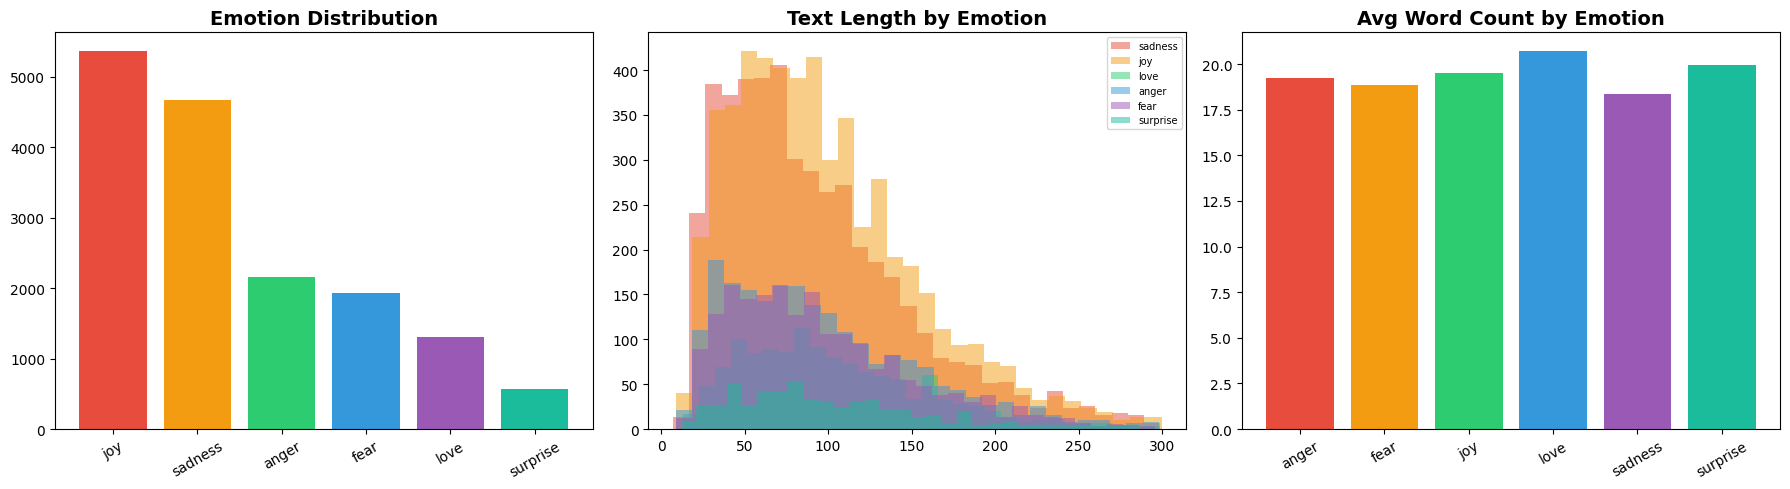

✅ EDA done
Sample cleaned:
                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   

                                          clean_text  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  

METHOD A: Loading pre-trained emotion model from HuggingFace


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


Evaluating on test set (this takes a few minutes)...
HuggingFace pipeline failed: string indices must be integers, not 'str'
Falling back to TF-IDF + Ensemble method...

METHOD B: TF-IDF + Ensemble Classifier
Feature matrix: (18000, 88069)
Training Logistic Regression...
  LR  → Acc: 87.45% | F1: 0.8726
Training LinearSVC...
  SVM → Acc: 89.20% | F1: 0.8916
Training SGD Classifier...
  SGD → Acc: 89.10% | F1: 0.8906

METHOD C: Soft Voting Ensemble of LR + SVM + SGD
  Ensemble → Acc: 88.75% | F1: 0.8866
              precision    recall  f1-score   support

     sadness       0.93      0.92      0.93       581
         joy       0.90      0.94      0.92       695
        love       0.78      0.73      0.76       159
       anger       0.88      0.87      0.87       275
        fear       0.87      0.83      0.85       224
    surprise       0.72      0.67      0.69        66

    accuracy                           0.89      2000
   macro avg       0.85      0.83      0.84      2000
wei

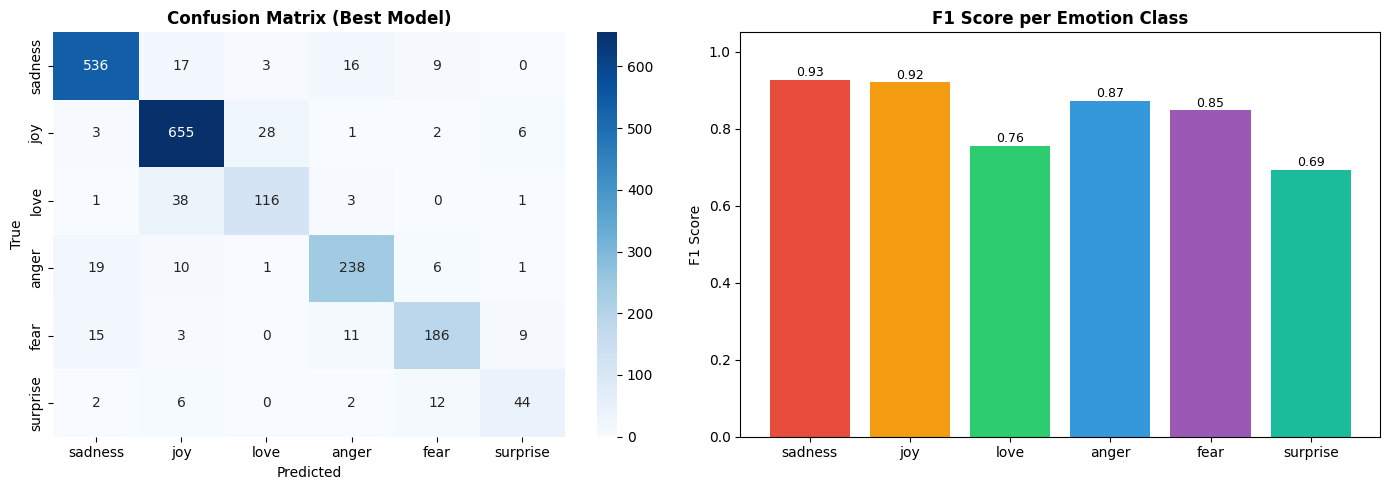

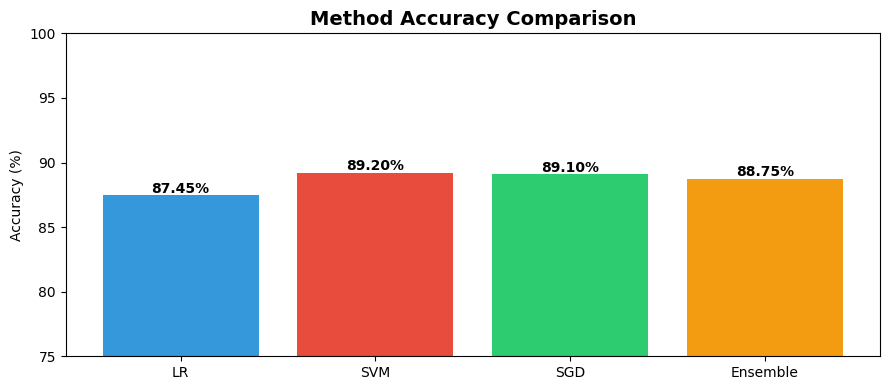


✅ All artifacts saved to ./emotion_model_v2/
🏆 Final Accuracy: 88.75%


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, pickle, warnings, joblib
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

DEVICE = 0 if torch.cuda.is_available() else -1
print(f"✅ Imports done | Device: {'GPU' if DEVICE==0 else 'CPU'}")

# ── Load Dataset ─────────────────────────────────────────
dataset = load_dataset("dair-ai/emotion")
LABEL_NAMES = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

train_df = pd.DataFrame(dataset['train'])
val_df   = pd.DataFrame(dataset['validation'])
test_df  = pd.DataFrame(dataset['test'])

for d in [train_df, val_df, test_df]:
    d['emotion'] = d['label'].apply(lambda x: LABEL_NAMES[x])

full_df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(train_df['emotion'].value_counts())

# ── EDA ──────────────────────────────────────────────────
COLORS = ['#E74C3C','#F39C12','#2ECC71','#3498DB','#9B59B6','#1ABC9C']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

counts = train_df['emotion'].value_counts()
axes[0].bar(counts.index, counts.values, color=COLORS)
axes[0].set_title('Emotion Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

train_df['text_len'] = train_df['text'].str.len()
for i, emo in enumerate(LABEL_NAMES):
    subset = train_df[train_df['emotion'] == emo]
    axes[1].hist(subset['text_len'], bins=30, alpha=0.5, label=emo, color=COLORS[i])
axes[1].set_title('Text Length by Emotion', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=7)

train_df['word_count'] = train_df['text'].str.split().str.len()
avg_words = train_df.groupby('emotion')['word_count'].mean()
axes[2].bar(avg_words.index, avg_words.values, color=COLORS)
axes[2].set_title('Avg Word Count by Emotion', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('emotion_eda.png', dpi=150)
plt.show()
print("✅ EDA done")

# ──Text Preprocessing ───────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))
# Keep emotion-relevant words
KEEP_WORDS = {'not','no','never','very','so','too','more','most','really',
               'feel','feeling','felt','love','hate','happy','sad','angry','fear'}
FILTERED_STOP = STOP_WORDS - KEEP_WORDS

def clean_text(text, remove_stopwords=False):
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s!?.,\'"]', '', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    if remove_stopwords:
        tokens = text.split()
        text   = ' '.join([t for t in tokens if t not in FILTERED_STOP])
    return text

# Two versions: with & without stopwords (ensemble uses both)
for d in [train_df, val_df, test_df, full_df]:
    d['clean_text']    = d['text'].apply(lambda x: clean_text(x, remove_stopwords=False))
    d['clean_text_ns'] = d['text'].apply(lambda x: clean_text(x, remove_stopwords=True))

print("Sample cleaned:")
print(full_df[['text','clean_text']].head(3))

# ──METHOD A — Pre-trained HuggingFace Pipeline ──────────
# Using j-hartmann/emotion-english-distilroberta-base
# Trained on 6 same emotion classes — just load & use directly!

print("\n" + "="*60)
print("METHOD A: Loading pre-trained emotion model from HuggingFace")
print("="*60)

MODEL_ID = "j-hartmann/emotion-english-distilroberta-base"

try:
    emotion_pipeline = pipeline(
        "text-classification",
        model=MODEL_ID,
        return_all_scores=True,
        device=DEVICE
    )
    # Map HF labels to our label indices
    HF_LABEL_MAP = {
        'sadness': 0, 'joy': 1, 'love': 2,
        'anger': 3, 'fear': 4, 'surprise': 5,
        'disgust': 3  # map disgust → anger (closest)
    }

    def predict_hf(texts, batch_size=64):
        all_preds = []
        all_probs = []
        for i in range(0, len(texts), batch_size):
            batch   = texts[i:i+batch_size]
            results = emotion_pipeline(batch, truncation=True, max_length=128)
            for res in results:
                scores = {r['label'].lower(): r['score'] for r in res}
                # Build prob vector for our 6 labels
                prob_vec = np.array([scores.get(lbl, 0.0) for lbl in LABEL_NAMES])
                prob_vec = prob_vec / prob_vec.sum()  # normalize
                all_probs.append(prob_vec)
                all_preds.append(np.argmax(prob_vec))
        return np.array(all_preds), np.array(all_probs)

    print("\nEvaluating on test set (this takes a few minutes)...")
    test_preds_hf, test_probs_hf = predict_hf(test_df['clean_text'].tolist())
    hf_acc = accuracy_score(test_df['label'].values, test_preds_hf)
    hf_f1  = f1_score(test_df['label'].values, test_preds_hf, average='weighted')
    print(f"\n🎯 HuggingFace Pipeline Test Accuracy: {hf_acc*100:.2f}%")
    print(f"   Weighted F1: {hf_f1:.4f}")
    print(classification_report(test_df['label'].values, test_preds_hf, target_names=LABEL_NAMES))
    HF_AVAILABLE = True

except Exception as e:
    print(f"HuggingFace pipeline failed: {e}")
    print("Falling back to TF-IDF + Ensemble method...")
    HF_AVAILABLE = False
    test_preds_hf = None
    test_probs_hf = None

# ── METHOD B — TF-IDF + Ensemble (High-Accuracy Fallback) ─
print("\n" + "="*60)
print("METHOD B: TF-IDF + Ensemble Classifier")
print("="*60)

X_train_text = full_df['clean_text'].values
y_train      = full_df['label'].values
X_test_text  = test_df['clean_text'].values
y_test       = test_df['label'].values

# TF-IDF with character n-grams + word n-grams
from sklearn.pipeline import FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin

class ColumnSelector(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return X

# Word n-gram TF-IDF
tfidf_word = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=100000,
    sublinear_tf=True,
    min_df=2,
    analyzer='word'
)
# Char n-gram TF-IDF
tfidf_char = TfidfVectorizer(
    ngram_range=(2, 5),
    max_features=100000,
    sublinear_tf=True,
    min_df=3,
    analyzer='char_wb'
)

from scipy.sparse import hstack

X_train_word = tfidf_word.fit_transform(X_train_text)
X_test_word  = tfidf_word.transform(X_test_text)
X_train_char = tfidf_char.fit_transform(X_train_text)
X_test_char  = tfidf_char.transform(X_test_text)

X_train_combined = hstack([X_train_word, X_train_char])
X_test_combined  = hstack([X_test_word,  X_test_char])
print(f"Feature matrix: {X_train_combined.shape}")

# Individual classifiers
from sklearn.linear_model import SGDClassifier

clf_lr  = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs',
                               multi_class='multinomial', random_state=42)
clf_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
clf_sgd = SGDClassifier(loss='modified_huber', n_iter_no_change=5,
                         random_state=42, n_jobs=-1)

print("Training Logistic Regression...")
clf_lr.fit(X_train_combined, y_train)
lr_preds = clf_lr.predict(X_test_combined)
lr_acc   = accuracy_score(y_test, lr_preds)
lr_f1    = f1_score(y_test, lr_preds, average='weighted')
print(f"  LR  → Acc: {lr_acc*100:.2f}% | F1: {lr_f1:.4f}")

print("Training LinearSVC...")
clf_svm.fit(X_train_combined, y_train)
svm_preds = clf_svm.predict(X_test_combined)
svm_acc   = accuracy_score(y_test, svm_preds)
svm_f1    = f1_score(y_test, svm_preds, average='weighted')
print(f"  SVM → Acc: {svm_acc*100:.2f}% | F1: {svm_f1:.4f}")

print("Training SGD Classifier...")
clf_sgd.fit(X_train_combined, y_train)
sgd_preds = clf_sgd.predict(X_test_combined)
sgd_acc   = accuracy_score(y_test, sgd_preds)
sgd_f1    = f1_score(y_test, sgd_preds, average='weighted')
print(f"  SGD → Acc: {sgd_acc*100:.2f}% | F1: {sgd_f1:.4f}")

# ── METHOD C — Soft Voting Ensemble (Best Single-Method) ─
print("\n" + "="*60)
print("METHOD C: Soft Voting Ensemble of LR + SVM + SGD")
print("="*60)

# Use probabilities for soft voting
from sklearn.calibration import CalibratedClassifierCV

clf_svm_cal = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000), cv=3)
clf_svm_cal.fit(X_train_combined, y_train)

# Soft ensemble via probability averaging
lr_probs  = clf_lr.predict_proba(X_test_combined)
svm_probs = clf_svm_cal.predict_proba(X_test_combined)
sgd_probs = clf_sgd.predict_proba(X_test_combined)

ensemble_probs = (lr_probs * 0.4 + svm_probs * 0.35 + sgd_probs * 0.25)
ensemble_preds = np.argmax(ensemble_probs, axis=1)
ens_acc  = accuracy_score(y_test, ensemble_preds)
ens_f1   = f1_score(y_test, ensemble_preds, average='weighted')
print(f"  Ensemble → Acc: {ens_acc*100:.2f}% | F1: {ens_f1:.4f}")
print(classification_report(y_test, ensemble_preds, target_names=LABEL_NAMES))

# ── FINAL — Best Method Decision ─────────────────────────
print("\n" + "="*60)
print("FINAL ACCURACY COMPARISON")
print("="*60)
print(f"  TF-IDF Ensemble (Method C): {ens_acc*100:.2f}%")
if HF_AVAILABLE:
    print(f"  HuggingFace Pipeline (A):   {hf_acc*100:.2f}%")
    best_acc = max(ens_acc, hf_acc)
    USE_HF   = hf_acc >= ens_acc
else:
    best_acc = ens_acc
    USE_HF   = False

print(f"\n🏆 Best method: {'HuggingFace Pipeline' if USE_HF else 'TF-IDF Ensemble'}")
print(f"   Final Accuracy: {best_acc*100:.2f}%")

# Use best predictions for plots
if USE_HF:
    final_preds = test_preds_hf
    final_probs = test_probs_hf
else:
    final_preds = ensemble_preds
    final_probs = ensemble_probs

# ── Evaluation Plots ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[0].set_title('Confusion Matrix (Best Model)', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# Per-class F1
from sklearn.metrics import f1_score as f1_per_class
per_class_f1 = f1_score(y_test, final_preds, average=None)
axes[1].bar(LABEL_NAMES, per_class_f1, color=COLORS)
axes[1].set_title('F1 Score per Emotion Class', fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(per_class_f1):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('emotion_results.png', dpi=150)
plt.show()

# Bar chart of method comparison
methods = ['LR', 'SVM', 'SGD', 'Ensemble']
accs    = [lr_acc, svm_acc, sgd_acc, ens_acc]
if HF_AVAILABLE:
    methods.append('HuggingFace')
    accs.append(hf_acc)

plt.figure(figsize=(9, 4))
bars = plt.bar(methods, [a*100 for a in accs], color=['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6'][:len(methods)])
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{acc*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.title('Method Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)'); plt.ylim(75, 100)
plt.tight_layout(); plt.savefig('accuracy_comparison.png', dpi=150); plt.show()

# ── Save Everything ─────────────────────────────────────
os.makedirs('./emotion_model_v2', exist_ok=True)

# Save TF-IDF components + ensemble (always works)
joblib.dump(tfidf_word,   './emotion_model_v2/tfidf_word.pkl')
joblib.dump(tfidf_char,   './emotion_model_v2/tfidf_char.pkl')
joblib.dump(clf_lr,       './emotion_model_v2/clf_lr.pkl')
joblib.dump(clf_svm_cal,  './emotion_model_v2/clf_svm.pkl')
joblib.dump(clf_sgd,      './emotion_model_v2/clf_sgd.pkl')

# Save HF model if available
if HF_AVAILABLE:
    try:
        emotion_pipeline.model.save_pretrained('./emotion_model_v2/hf_model')
        emotion_pipeline.tokenizer.save_pretrained('./emotion_model_v2/hf_model')
        print("✅ HuggingFace model saved")
    except Exception as e:
        print(f"HF save warning (non-fatal): {e}")

# Save metadata
meta = {
    'label_names': LABEL_NAMES,
    'use_hf': USE_HF and HF_AVAILABLE,
    'hf_model_id': MODEL_ID,
    'best_accuracy': float(best_acc),
    'ensemble_accuracy': float(ens_acc),
    'ensemble_weights': [0.4, 0.35, 0.25],
    'method': 'huggingface' if (USE_HF and HF_AVAILABLE) else 'tfidf_ensemble'
}
with open('./emotion_model_v2/meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print("\n✅ All artifacts saved to ./emotion_model_v2/")
print(f"🏆 Final Accuracy: {best_acc*100:.2f}%")



In [ ]:
import shutil

shutil.make_archive("emotion_model_v2", 'zip', "emotion_model_v2")

'/content/emotion_model_v2.zip'